In [69]:
"""
octave_introduction.py: shows the basic commands to control the octave's clock, synthesizers, up-converters, triggers,
down-converters and calibration
"""

from qm.QuantumMachinesManager import QuantumMachinesManager
from qm.octave import *
from qm.octave.octave_manager import ClockMode
from qm.qua import *
import os
import time
import matplotlib.pyplot as plt
from qualang_tools.units import unit
import numpy as np

%matplotlib notebook

# Flags to switch between different modes defined below
check_up_converters = False
check_triggers = False
check_down_converters = False
calibration = False

#################################
# Step 0 : Octave configuration #
#################################
opx_ip = "192.168.88.252"
opx_port = 9510
octave_ip = "192.168.88.254"
octave_port = 80
con = "con1"
octave = "octave1"
# The elements used to test the ports of the Octave
elements = ["qe1", "qe2", "qe3", "qe4", "qe5"]
IF = 50e6  # The IF frequency
LO = 6e9  # The LO frequency
# The configuration used here
config = {
    "version": 1,
    "controllers": {
        con: {
            "analog_outputs": {
                1: {"offset": 0.0},
                2: {"offset": 0.0},
                3: {"offset": 0.0},
                4: {"offset": 0.0},
                5: {"offset": 0.0},
                6: {"offset": 0.0},
                7: {"offset": 0.0},
                8: {"offset": 0.0},
                9: {"offset": 0.0},
                10: {"offset": 0.0},
            },
            "digital_outputs": {
                1: {},
                2: {},
                3: {},
                4: {},
                5: {},
            },
            "analog_inputs": {
                1: {"offset": +0.0},
                2: {"offset": +0.0},
            },
        }
    },
    "elements": {
        "qe1": {
            "mixInputs": {
                "I": (con, 1),
                "Q": (con, 2),
                "lo_frequency": LO,
                "mixer": f"octave_{octave}_1",  # a fixed name, do not change.
            },
            "intermediate_frequency": IF,
            "operations": {
                "cw": "const",
                "cw_wo_trig": "const_wo_trig",
                "readout": "readout_pulse",
            },
            "digitalInputs": {
                "switch": {
                    "port": (con, 1),
                    "delay": 136,
                    "buffer": 0,
                },
            },
            "outputs": {
                "out1": (con, 1),
                "out2": (con, 2),
            },
            "time_of_flight": 24,
            "smearing": 0,
        },
        "qe2": {
            "mixInputs": {
                "I": (con, 3),
                "Q": (con, 4),
                "lo_frequency": LO,
                "mixer": f"octave_{octave}_2",  # a fixed name, do not change.
            },
            "intermediate_frequency": IF,
            "operations": {
                "cw": "const",
                "cw_wo_trig": "const_wo_trig",
                "readout": "readout_pulse",
            },
            "digitalInputs": {
                "switch": {
                    "port": (con, 2),
                    "delay": 136,
                    "buffer": 0,
                },
            },
            "outputs": {
                "out1": (con, 1),
                "out2": (con, 2),
            },
            "time_of_flight": 24,
            "smearing": 0,
        },
        "qe3": {
            "mixInputs": {
                "I": (con, 5),
                "Q": (con, 6),
                "lo_frequency": LO,
                "mixer": f"octave_{octave}_3",  # a fixed name, do not change.
            },
            "intermediate_frequency": IF,
            "operations": {
                "cw": "const",
                "cw_wo_trig": "const_wo_trig",
            },
            "digitalInputs": {
                "switch": {
                    "port": (con, 3),
                    "delay": 136,
                    "buffer": 0,
                },
            },
        },
        "qe4": {
            "mixInputs": {
                "I": (con, 7),
                "Q": (con, 8),
                "lo_frequency": LO,
                "mixer": f"octave_{octave}_4",  # a fixed name, do not change.
            },
            "intermediate_frequency": IF,
            "operations": {
                "cw": "const",
                "cw_wo_trig": "const_wo_trig",
            },
            "digitalInputs": {
                "switch": {
                    "port": (con, 4),
                    "delay": 136,
                    "buffer": 0,
                },
            },
        },
        "qe5": {
            "mixInputs": {
                "I": (con, 9),
                "Q": (con, 10),
                "lo_frequency": LO,
                "mixer": f"octave_{octave}_5",  # a fixed name, do not change.
            },
            "intermediate_frequency": IF,
            "operations": {
                "cw": "const",
                "cw_wo_trig": "const_wo_trig",
            },
            "digitalInputs": {
                "switch": {
                    "port": (con, 5),
                    "delay": 136,
                    "buffer": 0,
                },
            },
        },
    },
    "pulses": {
        "const": {
            "operation": "control",
            "length": 1000,
            "waveforms": {
                "I": "const_wf",
                "Q": "zero_wf",
            },
            "digital_marker": "ON",
        },
        "const_wo_trig": {
            "operation": "control",
            "length": 1000,
            "waveforms": {
                "I": "const_wf",
                "Q": "zero_wf",
            },
        },
        "readout_pulse": {
            "operation": "measurement",
            "length": 1000,
            "waveforms": {
                "I": "readout_wf",
                "Q": "zero_wf",
            },
            "integration_weights": {
                "cos": "cosine_weights",
                "sin": "sine_weights",
                "minus_sin": "minus_sine_weights",
            },
            "digital_marker": "ON",
        },
    },
    "waveforms": {
        "zero_wf": {
            "type": "constant",
            "sample": 0.0,
        },
        "const_wf": {
            "type": "constant",
            "sample": 0.125,
        },
        "readout_wf": {
            "type": "constant",
            "sample": 0.125,
        },
    },
    "digital_waveforms": {
        "ON": {"samples": [(1, 0)]},
        "OFF": {"samples": [(0, 0)]},
    },
    "integration_weights": {
        "cosine_weights": {
            "cosine": [(1.0, 1000)],
            "sine": [(0.0, 1000)],
        },
        "sine_weights": {
            "cosine": [(0.0, 1000)],
            "sine": [(1.0, 1000)],
        },
        "minus_sine_weights": {
            "cosine": [(0.0, 1000)],
            "sine": [(-1.0, 1000)],
        },
    },
    "mixers": {
        f"octave_{octave}_1": [
            {
                "intermediate_frequency": IF,
                "lo_frequency": LO,
                "correction": (1, 0, 0, 1),
            },
        ],
        f"octave_{octave}_2": [
            {
                "intermediate_frequency": IF,
                "lo_frequency": LO,
                "correction": (1, 0, 0, 1),
            },
        ],
        f"octave_{octave}_3": [
            {
                "intermediate_frequency": IF,
                "lo_frequency": LO,
                "correction": (1, 0, 0, 1),
            },
        ],
        f"octave_{octave}_4": [
            {
                "intermediate_frequency": IF,
                "lo_frequency": LO,
                "correction": (1, 0, 0, 1),
            },
        ],
        f"octave_{octave}_5": [
            {
                "intermediate_frequency": IF,
                "lo_frequency": LO,
                "correction": (1, 0, 0, 1),
            },
        ],
    },
}

# Create the octave config object
octave_config = QmOctaveConfig()
# Specify where to store the outcome of the calibration (correction matrix, offsets...)
octave_config.set_calibration_db(os.getcwd())
# Add an Octave called 'octave1' with the specified IP and port
octave_config.add_device_info(octave, octave_ip, octave_port)
# Define the connectivity between our Octave to the OPX(s) ports. The 'default'
# connectivity is as follows:
#    +- OCTAVE (octavfqoe1) --------------------------------------------------------+
#    |                                      I1    I2    I3    I4    I5           |
#    |             o    o    o    o    o     o<+   o<+   o<+   o<+   o<+     o   |
#    |   o    o                           QM   |     |     |     |     |         |
#    |             o    o    o    o    o   +>o | +>o | +>o | +>o | +>o |     o   |
#    |                                     |Q1 | |Q2 | |Q3 | |Q4 | |Q5 |         |
#    +-------------------------------------|---|-|---|-|---|-|---|-|---|---------+
#                                          |   | |   | |   | |   | |   |
#                                          |   | |   | |   | |   | |   |
#    +- OPX (con1) ------------------------|---|-|---|-|---|-|---|-|---|---------+
#    |                                     | 1 | | 3 | | 5 | | 7 | | 9 |         |
#    |     o     o     o     o     o    |  | o<+ | o<+ | o<+ | o<+ | o<+ |   o   |
#    |                                     |     |     |     |     |             |
#    |     o     o     o     o     o    |  +>o   +>o   +>o   +>o   +>o   |   o   |
#    |                                       2     4     6     8    10           |
#    +---------------------------------------------------------------------------+
octave_config.set_opx_octave_mapping([(con, octave)])
# The last command is equivalent to
# octave_config.add_opx_octave_port_mapping({
#     ('con1',  1) : ('octave1', 'I1'),
#     ('con1',  2) : ('octave1', 'Q1'),
#     ('con1',  3) : ('octave1', 'I2'),
#     ('con1',  4) : ('octave1', 'Q2'),
#     ('con1',  5) : ('octave1', 'I3'),
#     ('con1',  6) : ('octave1', 'Q3'),
#     ('con1',  7) : ('octave1', 'I4'),
#     ('con1',  8) : ('octave1', 'Q4'),
#     ('con1',  9) : ('octave1', 'I5'),
#     ('con1', 10) : ('octave1', 'Q5'),
# })

# Open the QuantumMachineManager for the OPX and Octave
qmm = QuantumMachinesManager(host=opx_ip, port=opx_port, octave=octave_config)
# Open a quantum machine to calibrate the ports or play signals
qm = qmm.open_qm(config)

# Simple test program that plays a continuous wave through all ports
with program() as hello_octave:
    with infinite_loop_():
        for el in elements:
            play("cw", el)

###########################
# Step 1 : clock settings #
###########################
external_clock = False
if external_clock:
    # Change to the relevant external frequency
    qm.octave.set_clock(octave, clock_mode=ClockMode.External_10MHz)
else:
    qm.octave.set_clock(octave, clock_mode=ClockMode.Internal)
# You can connect clock out from rear panel to a spectrum analyzer  to see the 1GHz signal

#########################################
# Step 2 : set LO, RF gain, and RF mode #
#########################################
external_LO = False
# For external LO only:
if external_LO:
    # OctaveLOSource.LO1,2,3,4,5 to use an external LO source connected to the corresponding ports in the rear panel.
    qm.octave.set_lo_source(elements[1], OctaveLOSource.LO2)
    qm.octave.set_rf_output_gain(elements[1], 0)  # can set the gain from -10dB to 20dB
    qm.octave.set_rf_output_mode(elements[1], RFOutputMode.on)  # set the behaviour of the RF switch to be 'on'.
# For internal LO only:
else:
    for el in elements:
        qm.octave.set_lo_source(el, OctaveLOSource.Internal)  # Use the internal synthetizer to generate the LO.
        qm.octave.set_lo_frequency(el, LO)  # assign the LO inside the octave to element
        qm.octave.set_rf_output_gain(el, 0)  # can set the gain from -10dB to 20dB
        qm.octave.set_rf_output_mode(el, RFOutputMode.on)  # set the behaviour of the RF switch to be 'on'.
        # 'RFOutputMode' can be : on, off, trig_normal or trig_inverse
        # You can check the internal LOs by connecting the ports synth1, 2 and 3 to a spectrum analyzer.

#######################################
# Step 3 : checking the up-converters #
#######################################
if check_up_converters:
    print("-" * 37 + " Checking up-converters")
    job = qm.execute(hello_octave)
    time.sleep(60)  # The program will run for 1 minute
    job.halt()
    # You can connect RF1, RF2, RF3, RF4, RF5 to a spectrum analyzer and check the 3 peaks before calibration:
    # 1. LO-IF, 2. LO, 3. LO+IF

2023-11-21 14:05:26,962 - qm - INFO     - Performing health check
2023-11-21 14:05:26,975 - qm - INFO     - Health check passed


C:\Users\measPC\AppData\Local\Temp\ipykernel_10276\2663552377.py:311: DeprecationWarning: OctaveConfig.set_opx_octave_mapping is deprecated as of 1.1.0 and will be removed in 1.2.0, The port mapping was moved to the config. Please set the mapping there
  octave_config.set_opx_octave_mapping([(con, octave)])
d:\anaconda3\lib\site-packages\qm\octave\octave_config.py:342: DeprecationWarning: Setting port mapping was moved to the config, please move your mapping there
  conns = self.get_opx_octave_port_mapping()
d:\anaconda3\lib\site-packages\qm\octave\octave_config.py:342: DeprecationWarning: Setting port mapping was moved to the config, please move your mapping there
  conns = self.get_opx_octave_port_mapping()
d:\anaconda3\lib\site-packages\qm\octave\octave_config.py:342: DeprecationWarning: Setting port mapping was moved to the config, please move your mapping there
  conns = self.get_opx_octave_port_mapping()
d:\anaconda3\lib\site-packages\qm\octave\octave_config.py:342: DeprecationWa

In [70]:
# Cell split so we could run only the trigger check

check_triggers = False
##################################
# Step 4 : checking the triggers #
##################################
if check_triggers:
    print("-" * 37 + " Checking triggers")
    # Connect RF1, RF2, RF3, RF4, RF5 to a spectrum analyzer and check that you get a signal for 4sec then don't get a signal fo 4 sec and so on.
    for el in elements:
        # set the behaviour of the RF switch to be on only when triggered
        qm.octave.set_rf_output_mode(el, RFOutputMode.trig_normal)
    with program() as hello_octave_trigger:
        with infinite_loop_():
            for el in elements:
                play("cw", el, duration=1e9)
                play("cw_wo_trig", el, duration=1e9)
    job = qm.execute(hello_octave_trigger)
    time.sleep(60)  #  The program will run for 1 minute
    job.halt()

In [71]:
import matplotlib.pyplot as plt
# Cell split so we could run only the check_triggers
calibration = False #remmeber to comment out -Taha
check_down_converters = False # THIS HAS BEEN CHANGED TO TRUE FROM ORIGINAL VALUE - ROB
#########################################
# Step 5 : checking the down-converters #
#########################################
for el in elements:# -- Taha edit
    # set the behaviour of the RF switch to be on only when triggered
    qm.octave.set_rf_output_mode(el, RFOutputMode.on)
if check_down_converters:
    print("-" * 37 + " Checking down-converters")
    # Connect RF1 -> RF1In, RF2 -> RF2In
    # Connect IFOUT1 -> AI1 , IFOUT2 -> AI2
    check_down_converter_1 = True
    check_down_converter_2 = False
    u = unit()
    if check_down_converter_1:
        # Reduce the Octave gain to avoid saturating the OPX ADC
        qm.octave.set_rf_output_gain(elements[0], -10)
        # Set the Octave down-conversion port to be RF1In1 for the first element "qe1"
        qm.octave.set_qua_element_octave_rf_in_port(elements[0], octave, 1)
        # Set the source of the down-conversion LO to be internal (only for RF1In1)
        qm.octave.set_downconversion(
            elements[0], lo_source=RFInputLOSource.Internal, if_mode_i=IFMode.direct, if_mode_q=IFMode.direct
        )
        with program() as hello_octave_readout_1:
            raw_ADC_1 = declare_stream(adc_trace=True)
            measure("readout", elements[0], raw_ADC_1)
            with stream_processing():
                raw_ADC_1.input1().save("adc_1")
                raw_ADC_1.input2().save("adc_2")
        # Execute the program
        job = qm.execute(hello_octave_readout_1)
        res = job.result_handles
        res.wait_for_all_values()
        # Plot the results
        fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,7))
        fig.suptitle("Inputs from down conversion 1")
        adc_1 = u.raw2volts(res.get("adc_1").fetch_all())
        ax1.plot(adc_1, label="Input 1")
        ax1.set_title("amp VS time Input 1")
        ax1.set_xlabel("Time [ns]")
        ax1.set_ylabel("Signal amplitude [V]")

        adc_2 = u.raw2volts(res.get("adc_2").fetch_all())
        ax2.plot(adc_2, label="Input 2")
        ax2.set_title("amp VS time Input 2")
        ax2.set_xlabel("Time [ns]")
        ax2.set_ylabel("Signal amplitude [V]")
        plt.tight_layout()

    if check_down_converter_2:
        # Reduce the Octave gain to avoid saturating the OPX ADC
        qm.octave.set_rf_output_gain(elements[1], -10) 
        # Set the Octave down-conversion port to be RF1In2 for the second element "qe2"
        qm.octave.set_qua_element_octave_rf_in_port(elements[1], octave, 2)
        # Set the source of the down-conversion LO to be external from the port Dmd2LO in the rear panel
        qm.octave.set_downconversion(
            elements[1], lo_source=RFInputLOSource.Dmd2LO, if_mode_i=IFMode.direct, if_mode_q=IFMode.direct
        )
        with program() as hello_octave_readout_2:
            raw_ADC_2 = declare_stream(adc_trace=True)
            measure("readout", elements[1], raw_ADC_2)
            with stream_processing():
                raw_ADC_2.input1().save("adc_1")
                raw_ADC_2.input2().save("adc_2")
        # Execute the program
        job = qm.execute(hello_octave_readout_2)
        res = job.result_handles
        res.wait_for_all_values()
        # Plot the results
        fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,5))
        fig.suptitle("Inputs from down conversion 2")
        adc_1 = u.raw2volts(res.get("adc_1").fetch_all())
        ax1.plot(adc_1, label="Input 1")
        ax1.set_title("amp VS time Input 1")
        ax1.set_xlabel("Time [ns]")
        ax1.set_ylabel("Signal amplitude [V]")

        adc_2 = u.raw2volts(res.get("adc_2").fetch_all())
        ax2.plot(adc_2, label="Input 2")
        ax2.set_title("amp VS time Input 2")
        ax2.set_xlabel("Time [ns]")
        ax2.set_ylabel("Signal amplitude [V]")
        plt.tight_layout()

#################################
# Step 6 : checking calibration #
#################################
if calibration:
    print("-" * 37 + " Play before calibration")
    # Step 5.1: Connect RF1 and run these lines in order to see the uncalibrated signal first
    job = qm.execute(hello_octave)
    time.sleep(10)  # The program will run for 10 seconds
    job.halt()
    # Step 5.2: Run this in order to calibrate
    for i in range(len(elements)):
        print("-" * 37 + f" Calibrates {elements[i]}")
        qm.octave.calibrate_element(elements[i], [(LO, IF)])  # can provide many pairs of LO & IFs.
        qm = qmm.open_qm(config)
    # Step 5.3: Run these and look at the spectrum analyzer and check if you get 1 peak at LO+IF (i.e. 6.05GHz)
    print("-" * 37 + " Play after calibration")
    job = qm.execute(hello_octave)
    time.sleep(30)  # The program will run for 30 seconds
    job.halt()

C:\Users\measPC\AppData\Local\Temp\ipykernel_10276\224180632.py:10: DeprecationWarning: QuantumMachine.octave is deprecated since "1.1.0" and will be removed in "1.2.0". Use ElementWithOctave instead. For further details, see elements API.
  qm.octave.set_rf_output_mode(el, RFOutputMode.on)
C:\Users\measPC\AppData\Local\Temp\ipykernel_10276\224180632.py:10: DeprecationWarning: QuantumMachine.octave is deprecated since "1.1.0" and will be removed in "1.2.0". Use ElementWithOctave instead. For further details, see elements API.
  qm.octave.set_rf_output_mode(el, RFOutputMode.on)
C:\Users\measPC\AppData\Local\Temp\ipykernel_10276\224180632.py:10: DeprecationWarning: QuantumMachine.octave is deprecated since "1.1.0" and will be removed in "1.2.0". Use ElementWithOctave instead. For further details, see elements API.
  qm.octave.set_rf_output_mode(el, RFOutputMode.on)
C:\Users\measPC\AppData\Local\Temp\ipykernel_10276\224180632.py:10: DeprecationWarning: QuantumMachine.octave is deprecated 

In [88]:
# Demodulation following QUA Documentation: 'Demodulation and Measurement', where config settings have already been set

with program() as demod_step:
    I = declare(fixed)
    Q = declare(fixed)
    raw_ADC_1 = declare_stream(adc_trace=True) #ADC Stream we are using
    measure('readout', 'qe1', raw_ADC_1,
            dual_demod.full('cos', 'out1', 'sin', 'out2', I),
            dual_demod.full('minus_sin', 'out1', 'cos', 'out2', Q))
    save(I, 'I')
    save(Q, 'Q')
    
    
def Get_output_voltage_as_function_of_initial_voltage(config):
    
    I_list = []
    Q_list = []
    ini_voltages = []
    test = range(3, 12, 1)
    V_in_hundredths = []
    
    original_config_voltage = config['waveforms']['readout_wf'].get('sample')
    print(f'Original Voltage from config for readout waveform sample: {original_config_voltage}.')
    
    for voltage in test:
        current_voltage = voltage/1000
        V_in_hundredths.append(current_voltage)
        
        config['waveforms']['readout_wf']['sample'] = current_voltage
        print(f'Current voltage beign run : {current_voltage}')
        
        # Create the octave config object
        octave_config = QmOctaveConfig()
        # Specify where to store the outcome of the calibration (correction matrix, offsets...)
        octave_config.set_calibration_db(os.getcwd())
        # Add an Octave called 'octave1' with the specified IP and port
        octave_config.add_device_info(octave, octave_ip, octave_port)
        
        # Open the QuantumMachineManager for the OPX and Octave
        qmm = QuantumMachinesManager(host=opx_ip, port=opx_port, octave=octave_config)
        # Open a quantum machine to calibrate the ports or play signals
        qm = qmm.open_qm(config)
        
        job = qm.execute(demod_step)
        res = job.result_handles
        res.wait_for_all_values()
        
        I = res.get("I").fetch(0)
        print(f'I type: {type(I)}')
        Q = res.get("Q").fetch(0)
        
        I_list.append(I[0][0])
        Q_list.append(Q[0][0])
        
    config['waveforms']['readout_wf']['sample'] = original_config_voltage
    
    print_dummy = config['waveforms']['readout_wf']['sample']
    print(f'Config value for readout waveform sample set back to {print_dummy}.')
    print(f'Config value for readout waveform sample = Original voltage from config readout waveform sample:',
         f'{original_config_voltage == print_dummy}.')
    
#     print(f'Config value for readout waveform sample set back to {config['waveforms']['readout_wf']['sample']}.')
#     print(f'Config value for readout waveform sample = Original voltage from config readout waveform sample:',
#          f'{original_config_voltage == config['waveforms']['readout_wf']['sample']}.')
        
    return {'I': I_list, 'Q': Q_list, 'Initial_Voltages': V_in_hundredths}

%matplotlib inline

def Graph_Voltage_Back_to_OPX_as_a_function_of_Voltage_From_OPX(dummy_dict):
    
    input_voltages = dummy_dict.get('Initial_Voltages')
    I = dummy_dict.get('I')
    Q = dummy_dict.get('Q')
    
    """
    Here, we plot the signal amplitude from the voltcheck function versus the initial voltage we put into the I port on the OPX.
    It should be linear.
    """

    fig, ax = plt.subplots(1,1, figsize=(10,10))

    plt.plot(input_voltages, I, label = "I")
    plt.plot(input_voltages, Q, label = "Q")


    ax.set_title("I vs input voltage")
    ax.set_xlabel("Input voltage [V]")
    ax.set_ylabel("I [V]")

    plt.legend()
    
    return plt.show

def sqrt_graph(dummy_dict):
    
    squared = []
    
    input_voltages = dummy_dict.get('Initial_Voltages')
    I = dummy_dict.get('I')
    Q = dummy_dict.get('Q')

    for i in range(len(I)):
        squared.append(np.sqrt(I[i]**2 + Q[i]**2))
    
    """
    Here, we plot the signal amplitude from the voltcheck function versus the initial voltage we put into the I port on the OPX.
    It should be linear.
    """

    fig, ax = plt.subplots(1,1, figsize=(10,10))

    plt.plot(input_voltages, squared)


    ax.set_title("sqrt(Q^2+I^2) vs input voltage")
    ax.set_xlabel("Input voltage [V]")
    ax.set_ylabel("Q [V]")

    return plt.show()
    

In [89]:
testing_dict = Get_output_voltage_as_function_of_initial_voltage(config)

Original Voltage from config for readout waveform sample: 0.125.
Current voltage beign run : 0.003
2023-11-21 14:17:39,869 - qm - INFO     - Performing health check
2023-11-21 14:17:39,879 - qm - INFO     - Health check passed
2023-11-21 14:17:40,484 - qm - INFO     - Sending program to QOP for compilation
2023-11-21 14:17:40,562 - qm - INFO     - Executing program
I type: <class 'numpy.ndarray'>
Current voltage beign run : 0.004
2023-11-21 14:17:40,936 - qm - INFO     - Performing health check
2023-11-21 14:17:40,950 - qm - INFO     - Health check passed
2023-11-21 14:17:41,247 - qm - INFO     - Sending program to QOP for compilation
2023-11-21 14:17:41,320 - qm - INFO     - Executing program
I type: <class 'numpy.ndarray'>
Current voltage beign run : 0.005
2023-11-21 14:17:41,697 - qm - INFO     - Performing health check
2023-11-21 14:17:41,711 - qm - INFO     - Health check passed
2023-11-21 14:17:42,120 - qm - INFO     - Sending program to QOP for compilation
2023-11-21 14:17:42,19

<function matplotlib.pyplot.show(close=None, block=None)>

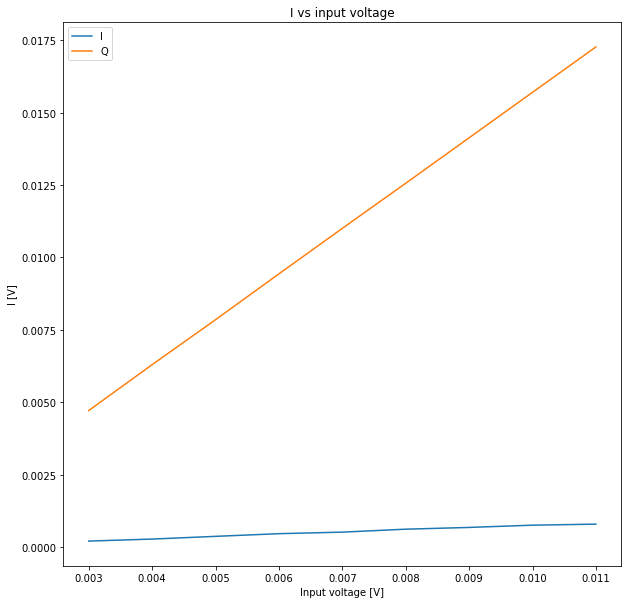

In [90]:
Graph_Voltage_Back_to_OPX_as_a_function_of_Voltage_From_OPX(testing_dict)

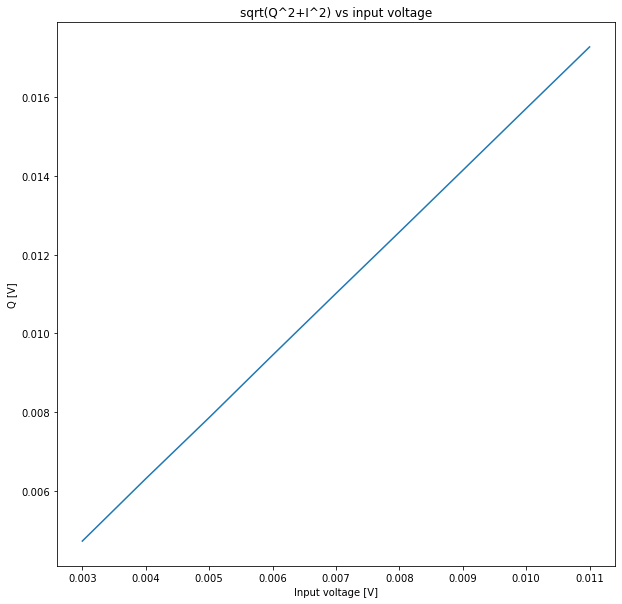

In [91]:
sqrt_graph(testing_dict)

In [84]:
config['waveforms']['readout_wf']['sample']

0.125

In [ ]:
'''waveform_tools.py => package that provides tools for easy waveform creation and manipulation '''

import numpy as np
from scipy.signal.windows import gaussian, blackman


def drag_gaussian_pulse_waveforms(
    amplitude,
    length,
    sigma,
    alpha,
    anharmonicity,
    detuning=0.0,
    subtracted=True,
    **kwargs
):
    """
    Creates Gaussian based DRAG waveforms that compensate for the leakage and for the AC stark shift.

    These DRAG waveforms has been implemented following the next Refs.:
    Chen et al. PRL, 116, 020501 (2016)
    https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.116.020501
    and Chen's thesis
    https://web.physics.ucsb.edu/~martinisgroup/theses/Chen2018.pdf

    :param float amplitude: The amplitude in volts.
    :param int length: The pulse length in ns.
    :param float sigma: The gaussian standard deviation.
    :param float alpha: The DRAG coefficient.
    :param float anharmonicity: f_21 - f_10 - The differences in energy between the 2-1 and the 1-0 energy levels, in Hz.
    :param float detuning: The frequency shift to correct for AC stark shift, in Hz.
    :param bool subtracted: If true, returns a subtracted Gaussian, such that the first and last points will be at 0
        volts. This reduces high-frequency components due to the initial and final points offset. Default is true.
    :return: Returns a tuple of two lists. The first list is the I waveform (real part) and the second is the
        Q waveform (imaginary part)
    """
    delta = kwargs.get("delta", None)
    if delta is not None:
        print(
            "'delta' has been replaced by 'anharmonicity' and will be deprecated in the future. "
        )
        if alpha != 0 and delta == 0:
            raise Exception("Cannot create a DRAG pulse with `anharmonicity=0`")
        t = np.arange(length, dtype=int)  # An array of size pulse length in ns
        center = (length - 1) / 2
        gauss_wave = amplitude * np.exp(
            -((t - center) ** 2) / (2 * sigma**2)
        )  # The gaussian function
        gauss_der_wave = (
            amplitude
            * (-2 * 1e9 * (t - center) / (2 * sigma**2))
            * np.exp(-((t - center) ** 2) / (2 * sigma**2))
        )  # The derivative of gaussian
        if subtracted:
            gauss_wave = gauss_wave - gauss_wave[-1]  # subtracted gaussian
        z = gauss_wave + 1j * 0
        if alpha != 0:
            # The complex DRAG envelope:
            z += 1j * gauss_der_wave * (alpha / (delta - 2 * np.pi * detuning))
            # The complex detuned DRAG envelope:
            z *= np.exp(1j * 2 * np.pi * detuning * t * 1e-9)
        I_wf = z.real.tolist()  # The `I` component is the real part of the waveform
        Q_wf = (
            z.imag.tolist()
        )  # The `Q` component is the imaginary part of the waveform
    else:
        if alpha != 0 and anharmonicity == 0:
            raise Exception("Cannot create a DRAG pulse with `anharmonicity=0`")
        t = np.arange(length, dtype=int)  # An array of size pulse length in ns
        center = (length - 1) / 2
        gauss_wave = amplitude * np.exp(
            -((t - center) ** 2) / (2 * sigma**2)
        )  # The gaussian function
        gauss_der_wave = (
            amplitude
            * (-2 * 1e9 * (t - center) / (2 * sigma**2))
            * np.exp(-((t - center) ** 2) / (2 * sigma**2))
        )  # The derivative of gaussian
        if subtracted:
            gauss_wave = gauss_wave - gauss_wave[-1]  # subtracted gaussian
        z = gauss_wave + 1j * 0
        if alpha != 0:
            # The complex DRAG envelope:
            z += (
                1j
                * gauss_der_wave
                * (alpha / (2 * np.pi * anharmonicity - 2 * np.pi * detuning))
            )
            # The complex detuned DRAG envelope:
            z *= np.exp(1j * 2 * np.pi * detuning * t * 1e-9)
        I_wf = z.real.tolist()  # The `I` component is the real part of the waveform
        Q_wf = (
            z.imag.tolist()
        )  # The `Q` component is the imaginary part of the waveform
    return I_wf, Q_wf


def drag_cosine_pulse_waveforms(
    amplitude, length, alpha, anharmonicity, detuning=0.0, **kwargs
):
    """
    Creates Cosine based DRAG waveforms that compensate for the leakage and for the AC stark shift.

    These DRAG waveforms has been implemented following the next Refs.:
    Chen et al. PRL, 116, 020501 (2016)
    https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.116.020501
    and Chen's thesis
    https://web.physics.ucsb.edu/~martinisgroup/theses/Chen2018.pdf

    :param float amplitude: The amplitude in volts.
    :param int length: The pulse length in ns.
    :param float alpha: The DRAG coefficient.
    :param float anharmonicity: f_21 - f_10 - The differences in energy between the 2-1 and the 1-0 energy levels, in Hz.
    :param float detuning: The frequency shift to correct for AC stark shift, in Hz.
    :return: Returns a tuple of two lists. The first list is the I waveform (real part) and the second is the
        Q waveform (imaginary part)
    """
    delta = kwargs.get("delta", None)
    if delta is not None:
        print(
            "'delta' has been replaced by 'anharmonicity' and will be deprecated in the future."
        )
        if alpha != 0 and anharmonicity == 0:
            raise Exception("Cannot create a DRAG pulse with `anharmonicity=0`")
        t = np.arange(length, dtype=int)  # An array of size pulse length in ns
        end_point = length - 1
        cos_wave = (
            0.5 * amplitude * (1 - np.cos(t * 2 * np.pi / end_point))
        )  # The cosine function
        sin_wave = (
            0.5
            * amplitude
            * (2 * np.pi / end_point * 1e9)
            * np.sin(t * 2 * np.pi / end_point)
        )  # The derivative of cosine function
        z = cos_wave + 1j * 0
        if alpha != 0:
            # The complex DRAG envelope:
            z += 1j * sin_wave * (alpha / (delta - 2 * np.pi * detuning))
            # The complex detuned DRAG envelope:
            z *= np.exp(1j * 2 * np.pi * detuning * t * 1e-9)
        I_wf = z.real.tolist()  # The `I` component is the real part of the waveform
        Q_wf = (
            z.imag.tolist()
        )  # The `Q` component is the imaginary part of the waveform
    else:
        if alpha != 0 and anharmonicity == 0:
            raise Exception("Cannot create a DRAG pulse with `anharmonicity=0`")
        t = np.arange(length, dtype=int)  # An array of size pulse length in ns
        end_point = length - 1
        cos_wave = (
            0.5 * amplitude * (1 - np.cos(t * 2 * np.pi / end_point))
        )  # The cosine function
        sin_wave = (
            0.5
            * amplitude
            * (2 * np.pi / end_point * 1e9)
            * np.sin(t * 2 * np.pi / end_point)
        )  # The derivative of cosine function
        z = cos_wave + 1j * 0
        if alpha != 0:
            # The complex DRAG envelope:
            z += (
                1j
                * sin_wave
                * (alpha / (2 * np.pi * anharmonicity - 2 * np.pi * detuning))
            )
            # The complex detuned DRAG envelope:
            z *= np.exp(1j * 2 * np.pi * detuning * t * 1e-9)
        I_wf = z.real.tolist()  # The `I` component is the real part of the waveform
        Q_wf = (
            z.imag.tolist()
        )  # The `Q` component is the imaginary part of the waveform
    return I_wf, Q_wf


def flattop_gaussian_waveform(
    amplitude, flat_length, rise_fall_length, return_part="all"
):
    """
    Returns a flat top Gaussian waveform. This is a square pulse with a rise and fall of a Gaussian with the given
    sigma. It is possible to only get the rising or falling parts, which allows scanning the flat part length from QUA.
    The length of the pulse will be the `flat_length + 2 * rise_fall_length`.

    :param float amplitude: The amplitude in volts.
    :param int flat_length: The flat part length in ns.
    :param int rise_fall_length: The rise and fall times in ns. The Gaussian sigma is given by the
        `rise_fall_length / 5`.
    :param str return_part: When set to 'all', returns the complete waveform. Default is 'all'. When set to 'rise',
    returns only the rising part. When set to 'fall', returns only the falling part. This is useful for separating
    the three parts which allows scanning the duration of the flat part is to scanned from QUA
    :return: Returns the waveform as a list of values with 1ns spacing
    """
    gauss_wave = amplitude * gaussian(2 * rise_fall_length, rise_fall_length / 5)

    rise_part = gauss_wave[:rise_fall_length]
    rise_part = rise_part.tolist()
    if return_part == "all":
        return rise_part + [amplitude] * flat_length + rise_part[::-1]
    elif return_part == "rise":
        return rise_part
    elif return_part == "fall":
        return rise_part[::-1]
    else:
        raise Exception("'return_part' must be either 'all', 'rise' or 'fall'")


def flattop_cosine_waveform(
    amplitude, flat_length, rise_fall_length, return_part="all"
):
    """
    Returns a flat top cosine waveform. This is a square pulse with a rise and fall with cosine shape with the given
    sigma. It is possible to only get the rising or falling parts, which allows scanning the flat part length from QUA.
    The length of the pulse will be the `flat_length + 2 * rise_fall_length`.

    :param float amplitude: The amplitude in volts.
    :param int flat_length: The flat part length in ns.
    :param int rise_fall_length: The rise and fall times in ns, taken as the time for a cosine to go from 0 to 1
    (pi phase-shift) and conversely.
    :param str return_part: When set to 'all', returns the complete waveform. Default is 'all'. When set to 'rise',
    returns only the rising part. When set to 'fall', returns only the falling part. This is useful for separating
    the three parts which allows scanning the duration of the flat part is to scanned from QUA
    :return: Returns the waveform as a list of values with 1ns spacing
    """
    rise_part = amplitude * 0.5 * (1 - np.cos(np.linspace(0, np.pi, rise_fall_length)))
    rise_part = rise_part.tolist()
    if return_part == "all":
        return rise_part + [amplitude] * flat_length + rise_part[::-1]
    elif return_part == "rise":
        return rise_part
    elif return_part == "fall":
        return rise_part[::-1]
    else:
        raise Exception("'return_part' must be either 'all', 'rise' or 'fall'")


def flattop_tanh_waveform(amplitude, flat_length, rise_fall_length, return_part="all"):
    """
    Returns a flat top tanh waveform. This is a square pulse with a rise and fall with tanh shape with the given
    sigma. It is possible to only get the rising or falling parts, which allows scanning the flat part length from QUA.
    The length of the pulse will be the `flat_length + 2 * rise_fall_length`.

    :param float amplitude: The amplitude in volts.
    :param int flat_length: The flat part length in ns.
    :param int rise_fall_length: The rise and fall times in ns, taken as a number of points of a tanh between -4
        and 4.
    :param str return_part: When set to 'all', returns the complete waveform. Default is 'all'. When set to 'rise',
    returns only the rising part. When set to 'fall', returns only the falling part. This is useful for separating
    the three parts which allows scanning the duration of the flat part is to scanned from QUA
    :return: Returns the waveform as a list of values with 1ns spacing
    """
    rise_part = amplitude * 0.5 * (1 + np.tanh(np.linspace(-4, 4, rise_fall_length)))
    rise_part = rise_part.tolist()
    if return_part == "all":
        return rise_part + [amplitude] * flat_length + rise_part[::-1]
    elif return_part == "rise":
        return rise_part
    elif return_part == "fall":
        return rise_part[::-1]
    else:
        raise Exception("'return_part' must be either 'all', 'rise' or 'fall'")


def flattop_blackman_waveform(
    amplitude, flat_length, rise_fall_length, return_part="all"
):
    """
    Returns a flat top Blackman waveform. This is a square pulse with a rise and fall with Blackman shape with the given
    length. It is possible to only get the rising or falling parts, which allows scanning the flat part length from QUA.
    The length of the pulse will be the `flat_length + 2 * rise_fall_length`.

    :param float amplitude: The amplitude in volts.
    :param int flat_length: The flat part length in ns.
    :param int rise_fall_length: The rise and fall times in ns, taken as the time to go from 0 to 'amplitude'.
    :param str return_part: When set to 'all', returns the complete waveform. Default is 'all'. When set to 'rise',
    returns only the rising part. When set to 'fall', returns only the falling part. This is useful for separating
    the three parts which allows scanning the duration of the  flat part is to scanned from QUA
    :return: Returns the waveform as a list
    """
    backman_wave = amplitude * blackman(2 * rise_fall_length)
    rise_part = backman_wave[:rise_fall_length]
    rise_part = rise_part.tolist()
    if return_part == "all":
        return rise_part + [amplitude] * flat_length + rise_part[::-1]
    elif return_part == "rise":
        return rise_part
    elif return_part == "fall":
        return rise_part[::-1]
    else:
        raise Exception("'return_part' must be either 'all', 'rise' or 'fall'")


def blackman_integral_waveform(pulse_length, v_start, v_end):
    """
    Returns a Blackman integral waveform. This is the integral of a Blackman waveform, adiabatically going from
    'v_start' to 'v_end' in 'pulse_length' ns.

    :param int pulse_length: The pulse length in ns.
    :param float v_start: The starting amplitude in volts.
    :param float v_end: The ending amplitude in volts.
    :return: Returns the waveform as a list
    """
    time = np.asarray([x * 1.0 for x in range(int(pulse_length))])
    black_wave = v_start + (
        time / (pulse_length - 1)
        - (25 / (42 * np.pi)) * np.sin(2 * np.pi * time / (pulse_length - 1))
        + (1 / (21 * np.pi)) * np.sin(4 * np.pi * time / (pulse_length - 1))
    ) * (v_end - v_start)
    return black_wave.tolist()